In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
import time

In [2]:
@cuda.jit
def mandelbrot_kernel(min_x, max_x, min_y, max_y,
                      image, max_iter):

    x, y = cuda.grid(2)

    height = image.shape[0]
    width = image.shape[1]

    if x < width and y < height:

        real = min_x + x * (max_x - min_x) / width
        imag = min_y + y * (max_y - min_y) / height

        c_real = real
        c_imag = imag

        z_real = 0.0
        z_imag = 0.0

        count = 0

        while (z_real * z_real + z_imag * z_imag <= 4.0
               and count < max_iter):

            temp = z_real * z_real - z_imag * z_imag + c_real

            z_imag = 2.0 * z_real * z_imag + c_imag
            z_real = temp

            count += 1

        image[y, x] = count

In [3]:
def mandelbrot_cpu(min_x, max_x, min_y, max_y,
                   width, height, max_iter):

    image = np.zeros((height, width), dtype=np.uint8)

    for y in range(height):

        for x in range(width):

            real = min_x + x * (max_x - min_x) / width
            imag = min_y + y * (max_y - min_y) / height

            z_real = 0.0
            z_imag = 0.0

            count = 0

            while (z_real * z_real + z_imag * z_imag <= 4.0
                   and count < max_iter):

                temp = z_real * z_real - z_imag * z_imag + real

                z_imag = 2.0 * z_real * z_imag + imag
                z_real = temp

                count += 1

            image[y, x] = count

    return image

In [4]:
width = 800
height = 800

max_iter = 100

min_x = -2.0
max_x = 1.0

min_y = -1.5
max_y = 1.5

In [5]:
start = time.time()

cpu_image = mandelbrot_cpu(
    min_x,
    max_x,
    min_y,
    max_y,
    width,
    height,
    max_iter
)

cpu_time = time.time() - start

print("CPU Time:", cpu_time, "seconds")

CPU Time: 1.803328275680542 seconds


In [8]:
image_gpu = np.zeros((height, width), dtype=np.uint8)

d_image = cuda.to_device(image_gpu)

threadsperblock = (16, 16)

blockspergrid_x = int(np.ceil(width / threadsperblock[0]))
blockspergrid_y = int(np.ceil(height / threadsperblock[1]))

blockspergrid = (blockspergrid_x, blockspergrid_y)

start = time.time()

mandelbrot_kernel[blockspergrid, threadsperblock](
    min_x,
    max_x,
    min_y,
    max_y,
    d_image,
    max_iter
)

cuda.synchronize()

gpu_time = time.time() - start

gpu_image = d_image.copy_to_host()

print("GPU Time:", gpu_time, "seconds")

GPU Time: 2.186558485031128 seconds


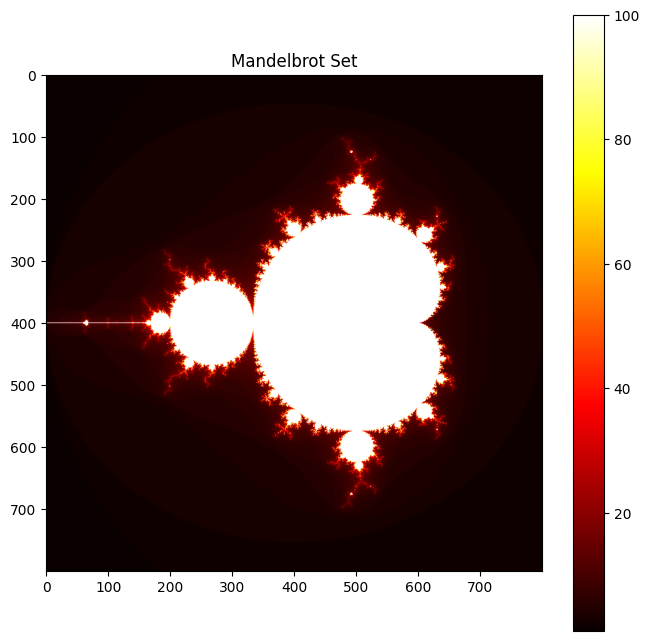

In [9]:
plt.figure(figsize=(8,8))

plt.imshow(gpu_image, cmap='hot')

plt.title("Mandelbrot Set")

plt.colorbar()

plt.show()